In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from joblib import parallel_backend
from sklearn.svm import SVR

In [4]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMWB_Train/MWB_TRAIN.csv"
path_test  = "dfFinalMWB_Test/MWB_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 1157 filas, 30 columnas
Dimensiones de Test:  321 filas, 30 columnas

--- Tipos de datos en Train ---
User_ID                          object
Age                               int64
Gender                           object
Occupation                       object
Relationship_Status              object
Primary_Platform                 object
Daily_Usage_Hours               float64
Platforms_Used_Count              int64
Posts_Per_Week                    int64
Late_Night_Usage                   bool
First_Check_Morning              object
Notifications_Per_Day             int64
FOMO_Score                      float64
Social_Comparison_Score         float64
Validation_Seeking_Score        float64
Scroll_Without_Purpose          float64
Tried_To_Cut_Back                  bool
Failed_To_Cut_Back                 bool
Anxiety_Score                   float64
Depression_Score                float64
Loneliness_Score             

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,2.9,4,3,False,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,LOW
1,USR00002,19,MALE,STUDENT,MARRIED,INSTAGRAM,4.8,1,0,True,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,SEVERE
2,USR00003,40,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,4.4,4,5,False,...,5.6,5.3,6.3,6.6,5.8,2.8,0.0,1.5,5.6,HIGH
3,USR00007,38,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,5.0,4,4,True,...,7.2,0.5,4.8,8.2,6.8,5.4,3.2,3.7,5.5,HIGH
4,USR00008,22,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,3.4,5,2,False,...,3.1,2.9,3.8,10.0,6.8,6.7,2.9,6.6,6.2,MODERATE


In [5]:
# 1. Definir la variable objetivo
target_col = "Mental_Wellbeing_Score"

columnas_a_dropear = [
    "User_ID",                 
    "Addiction_Level",         
    "Anxiety_Score",           
    "Depression_Score",       
    "Loneliness_Score",        
    "Self_Esteem_Score",       
    "FOMO_Score",              
    "Social_Comparison_Score", 
    "Validation_Seeking_Score",
    "Productivity_Loss_Score",
    "Sleep_Quality_Score"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (1157, 18)
Dimensiones de y_train (Objetivo):    (1157,)
Dimensiones de X_test (Predictoras):  (321, 18)
Dimensiones de y_test (Objetivo):     (321,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Late_Night_Usage', 'First_Check_Morning', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Tried_To_Cut_Back', 'Failed_To_Cut_Back', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']


In [6]:
# 1. Identificar cuáles son las columnas numéricas
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. Ajustar  y transformar
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                            -0.0
Daily_Usage_Hours               0.0
Platforms_Used_Count            0.0
Posts_Per_Week                 -0.0
Notifications_Per_Day          -0.0
Scroll_Without_Purpose          0.0
Sleep_Hours                    -0.0
Offline_Relationship_Quality    0.0
Physical_Activity_Hrs_Week      0.0
Screen_Free_Time_Hrs           -0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                             1.0
Daily_Usage_Hours               1.0
Platforms_Used_Count            1.0
Posts_Per_Week                  1.0
Notifications_Per_Day           1.0
Scroll_Without_Purpose          1.0
Sleep_Ho

,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,First_Check_Morning,Notifications_Per_Day,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Sleep_Hours,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs
0,0.067334,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,-0.789127,0.456438,-0.491000,False,WITHIN 5 MIN,0.058735,2.189671,False,False,-0.899325,-0.832606,1.667503,0.072920
1,-1.221326,MALE,STUDENT,MARRIED,INSTAGRAM,0.132625,-1.343900,-2.132871,True,WITHIN 5 MIN,1.544618,1.711265,True,True,-0.753349,-1.821444,-1.272773,0.196357
2,1.238843,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,-0.061428,0.456438,0.603580,False,WITHIN 5 MIN,1.878184,0.323886,False,True,0.049521,-1.327025,-1.812824,-0.914570
3,1.004541,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,0.229652,0.456438,0.056290,True,WITHIN 5 MIN,-1.093583,-1.350537,False,True,1.217331,-0.041536,0.107357,0.443229
4,-0.869873,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,-0.546561,1.056551,-1.038291,False,WITHIN 5 MIN,0.119383,-0.680768,True,False,2.531118,0.601208,-0.072660,2.233056


In [7]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform','First_Check_Morning']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test (Crucial)
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 31


In [8]:
display(X_train_codificado.head())

,Age,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,Notifications_Per_Day,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Sleep_Hours,...,Relationship_Status_SINGLE,Relationship_Status_UNKNOWN,Primary_Platform_INSTAGRAM,Primary_Platform_SNAPCHAT,Primary_Platform_TIKTOK,Primary_Platform_TWITTER/X,Primary_Platform_UNKNOWN,Primary_Platform_YOUTUBE,First_Check_Morning_AFTER 30 MIN,First_Check_Morning_WITHIN 5 MIN
0,0.067334,-0.789127,0.456438,-0.491000,False,0.058735,2.189671,False,False,-0.899325,...,False,False,False,False,False,False,False,True,False,True
1,-1.221326,0.132625,-1.343900,-2.132871,True,1.544618,1.711265,True,True,-0.753349,...,False,False,True,False,False,False,False,False,False,True
2,1.238843,-0.061428,0.456438,0.603580,False,1.878184,0.323886,False,True,0.049521,...,False,False,False,False,False,False,False,True,False,True
3,1.004541,0.229652,0.456438,0.056290,True,-1.093583,-1.350537,False,True,1.217331,...,False,False,False,False,False,False,False,False,False,True
4,-0.869873,-0.546561,1.056551,-1.038291,False,0.119383,-0.680768,True,False,2.531118,...,True,False,False,False,False,True,False,False,False,True


In [9]:
# 1. Definir el modelo base
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=46)

# 2. Definir la parrilla de hiperparámetros que quieres probar
param_grid = {
    'n_estimators': [50, 100, 200,500,1000,2000,5000,10000],       
    'learning_rate': [0.01, 0.05, 0.1,0.2],     
    'max_depth': range(1,10),                 
}

# 3. Configurar el GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',          
    cv=5,                  
    n_jobs=-1,             
    verbose=1              
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")
grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor R2 en Validación Cruzada: {grid_search.best_score_:.4f}")





--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 200}
Mejor R2 en Validación Cruzada: 0.4450


Primeras filas de los resultados de las combinaciones:


,param_max_depth,param_learning_rate,mean_test_score
0,1,0.01,0.126035
1,1,0.01,0.124447
2,1,0.01,0.120980
3,1,0.01,0.207524
4,1,0.01,0.204957


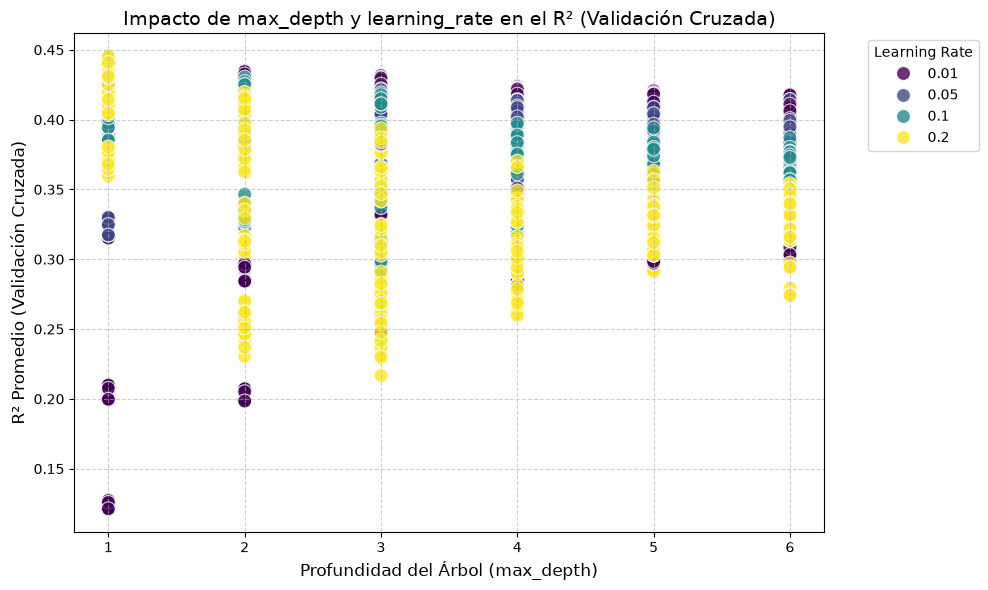

<Figure size 1000x800 with 0 Axes>

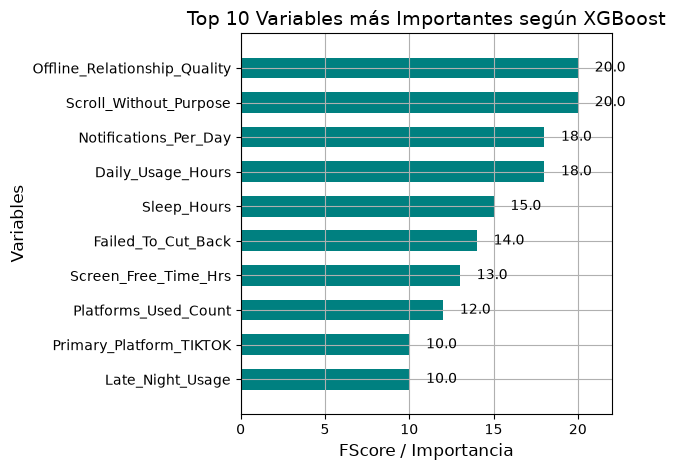

In [18]:
# 1. Convertir los resultados de la búsqueda en un DataFrame de Pandas
resultados_df = pd.DataFrame(grid_search.cv_results_) 

# 2. Vista previa de los datos recolectados
print("Primeras filas de los resultados de las combinaciones:")
display(resultados_df[['param_max_depth', 'param_learning_rate', 'mean_test_score']].head())

# ==========================================
# GRÁFICA 1: Impacto de 'max_depth' y 'learning_rate' en el R2
# ==========================================
plt.figure(figsize=(10, 6))

# Usamos un gráfico de dispersión  o línea para ver la tendencia
sns.scatterplot(
    data=resultados_df,
    x='param_max_depth',
    y='mean_test_score',
    hue='param_learning_rate',
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('Impacto de max_depth y learning_rate en el R² (Validación Cruzada)', fontsize=14)
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('R² Promedio (Validación Cruzada)', fontsize=12)
plt.legend(title='Learning Rate', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 2: Importancia de características del mejor modelo
# ==========================================
mejor_modelo = grid_search.best_estimator_

plt.figure(figsize=(10, 8))
# XGBoost incluye una función nativa para plotear la importancia
xgb.plot_importance(mejor_modelo, max_num_features=10, height=0.6, color='teal')
plt.title('Top 10 Variables más Importantes según XGBoost', fontsize=14)
plt.xlabel('FScore / Importancia', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# 5. Obtener el mejor modelo ya entrenado y evaluarlo en Test
best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test_codificado)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\n--- EVALUACIÓN FINAL EN TEST CON EL MEJOR MODELO ---")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R2:   {test_r2:.4f}")


--- EVALUACIÓN FINAL EN TEST CON EL MEJOR MODELO ---
Test RMSE: 0.9336
Test R2:   0.3937


--- Resultados en Test ---
RMSE: 0.9336
MAE:  0.7419
R2:   0.3937


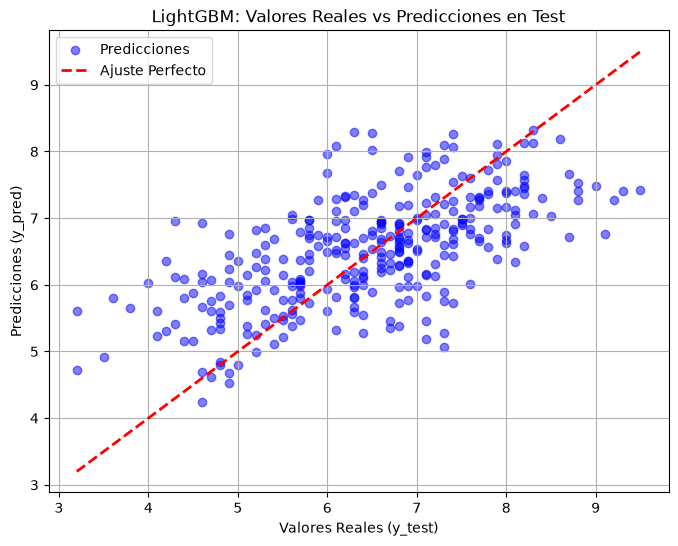

In [20]:
y_pred = grid_search.predict(X_test_codificado)

y_test_original = y_test

# 2. Métricas en escala real
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_test = mean_absolute_error(y_test_original, y_pred)
r2_test = r2_score(y_test_original, y_pred)

print("--- Resultados en Test ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R2:   {r2_test:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5, color='b', label='Predicciones')

min_val = min(np.min(y_test_original), np.min(y_pred))
max_val = max(np.max(y_test_original), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('LightGBM: Valores Reales vs Predicciones en Test')
plt.legend()
plt.grid(True)
plt.show()

best R2: 0.461
best parameters: {'C': np.float64(233.57214690901213), 'gamma': np.float64(0.0001)}
Gamma en la gráfica:  -4.0
C en la gráfica:  2.3684210526315788


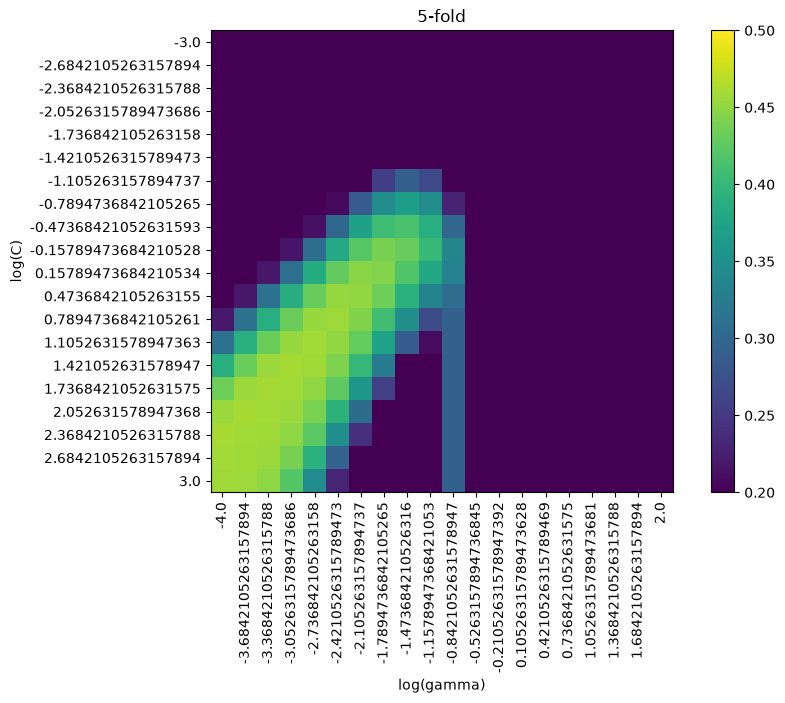

In [ ]:
# con SVM

vectorC = np.logspace(-3, 3, 20) 
vectorG = np.logspace(-4, 2, 20)

param_grid = {'C': vectorC, 'gamma':vectorG}

with parallel_backend('threading', n_jobs=4):
    grid = GridSearchCV(SVR(kernel='rbf'), param_grid=param_grid, cv = 5, scoring='r2')
    grid.fit(X_train_codificado, y_train)
print("best R2: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

print("Gamma en la gráfica: ", np.log10(grid.best_params_['gamma']))
print("C en la gráfica: ", np.log10(grid.best_params_['C']))

# Mostramos prestaciones en CV
scores = grid.cv_results_['mean_test_score'].reshape(len(vectorC),len(vectorG))

plt.figure(figsize=(10,6))
plt.imshow(scores, interpolation='nearest', vmin= 0.2, vmax=0.5)
plt.xlabel('log(gamma)')
plt.ylabel('log(C)')
plt.colorbar()
plt.xticks(np.arange(len(vectorG)), np.log10(vectorG), rotation=90)
plt.yticks(np.arange(len(vectorC)), np.log10(vectorC))
plt.title('5-fold')
plt.show()

--- Resultados en Test ---
RMSE: 0.8966
MAE:  0.7146
R2:   0.4408


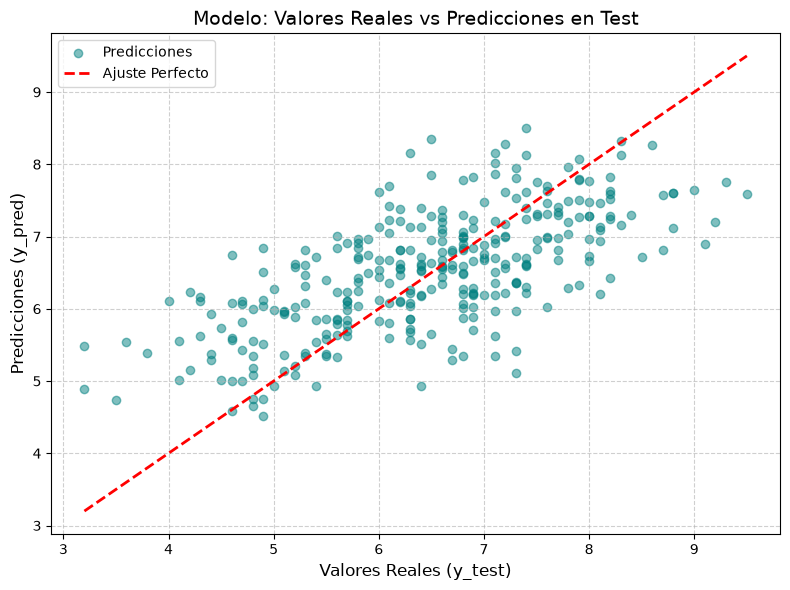

In [ ]:
# 1. Obtenemos las predicciones sobre el conjunto de Test usando el mejor modelo del GridSearch
y_pred = grid.best_estimator_.predict(X_test_codificado)  # Cambia 'grid' por 'grid_search' si así lo llamaste

y_test_original = y_test

# 2. Cálculo de métricas en escala real
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_test = mean_absolute_error(y_test_original, y_pred)
r2_test = r2_score(y_test_original, y_pred)

print("--- Resultados en Test ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R2:   {r2_test:.4f}")

# 3. Gráfica de dispersión: Valores Reales vs Predicciones
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5, color='teal', label='Predicciones')

# Línea diagonal de ajuste perfecto (y = x)
min_val = min(np.min(y_test_original), np.min(y_pred))
max_val = max(np.max(y_test_original), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

plt.xlabel('Valores Reales (y_test)', fontsize=12)
plt.ylabel('Predicciones (y_pred)', fontsize=12)
plt.title('Modelo: Valores Reales vs Predicciones en Test', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()